In [1]:
import pandas as pd
import numpy as np

In [2]:
admissions = pd.read_csv(r'C:\Users\Warner_Beast\.cache\kagglehub\datasets\antusaha182352543\mimic-iv-clinical-text-data\versions\1\admissions.csv')
diagnosis = pd.read_csv(r'C:\Users\Warner_Beast\.cache\kagglehub\datasets\antusaha182352543\mimic-iv-clinical-text-data\versions\1\diagnoses_icd.csv')
microbiology = pd.read_csv(r'C:\Users\Warner_Beast\.cache\kagglehub\datasets\antusaha182352543\mimic-iv-clinical-text-data\versions\1\microbiologyevents.csv')

C:\Users\Warner_Beast\AppData\Local\Temp\ipykernel_12160\1473003374.py:3: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  microbiology = pd.read_csv(r'C:\Users\Warner_Beast\.cache\kagglehub\datasets\antusaha182352543\mimic-iv-clinical-text-data\versions\1\microbiologyevents.csv')


In [10]:
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,EMERGENCY ROOM,NaN,Other,ENGLISH,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


In [8]:
admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431088 entries, 0 to 431087
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   subject_id            431088 non-null  int64 
 1   hadm_id               431088 non-null  int64 
 2   admittime             431088 non-null  object
 3   dischtime             431088 non-null  object
 4   deathtime             8625 non-null    object
 5   admission_type        431088 non-null  object
 6   admission_location    431088 non-null  object
 7   discharge_location    311774 non-null  object
 8   insurance             431088 non-null  object
 9   language              431088 non-null  object
 10  marital_status        421868 non-null  object
 11  race                  431088 non-null  object
 12  edregtime             299260 non-null  object
 13  edouttime             299260 non-null  object
 14  hospital_expire_flag  431088 non-null  int64 
dtypes: int64(3), obje

In [11]:
import pandas as pd

df = admissions

df = df.sort_values(["subject_id", "admittime"])

df["next_admit_datetime"] = df.groupby("subject_id")["admittime"].shift(-1)

df["days_to_readmit"] = (
    df["next_admit_datetime"] - df["dischtime"]
).dt.days

df["readmit_30d_flag"] = (
    (df["days_to_readmit"] >= 1) &
    (df["days_to_readmit"] <= 30)
).astype(int)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [14]:
import pandas as pd

df = admissions.copy()

# FORCE datetime conversion
df["admittime"] = pd.to_datetime(df["admittime"], errors="coerce")
df["dischtime"] = pd.to_datetime(df["dischtime"], errors="coerce")

# Sort correctly
df = df.sort_values(["subject_id", "admittime"])

# Next admission per patient
df["next_admit_datetime"] = (
    df.groupby("subject_id")["admittime"].shift(-1)
)

# Time difference
df["days_to_readmit"] = (
    df["next_admit_datetime"] - df["dischtime"]
).dt.days

# 30-day readmission flag
df["readmit_30d_flag"] = (
    (df["days_to_readmit"] >= 1) &
    (df["days_to_readmit"] <= 30)
).astype(int)


In [15]:
df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,next_admit_datetime,days_to_readmit,readmit_30d_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,2180-06-26 18:27:00,50.0,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,2180-07-23 12:35:00,25.0,1
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,2180-08-05 23:44:00,11.0,1
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0,NaT,NaN,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,EMERGENCY ROOM,NaN,Other,ENGLISH,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0,NaT,NaN,0


In [16]:
(df["days_to_readmit"] > 0)

0          True
1          True
3          True
2         False
4         False
          ...  
431084     True
431083    False
431086     True
431085    False
431087    False
Name: days_to_readmit, Length: 431088, dtype: bool

In [17]:
df

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,next_admit_datetime,days_to_readmit,readmit_30d_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,2180-06-26 18:27:00,50.0,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,2180-07-23 12:35:00,25.0,1
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,2180-08-05 23:44:00,11.0,1
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0,NaT,NaN,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,EMERGENCY ROOM,NaN,Other,ENGLISH,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0,NaT,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431084,19999828,29734428,2147-07-18 16:23:00,2147-08-04 18:10:00,NaN,EW EMER.,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,ENGLISH,SINGLE,WHITE,2147-07-17 17:18:00,2147-07-18 17:34:00,0,2149-01-08 16:44:00,522.0,0
431083,19999828,25744818,2149-01-08 16:44:00,2149-01-18 17:00:00,NaN,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Other,ENGLISH,SINGLE,WHITE,2149-01-08 09:11:00,2149-01-08 18:12:00,0,NaT,NaN,0
431086,19999840,26071774,2164-07-25 00:27:00,2164-07-28 12:15:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Other,ENGLISH,WIDOWED,WHITE,2164-07-24 21:16:00,2164-07-25 01:20:00,0,2164-09-10 13:47:00,44.0,0
431085,19999840,21033226,2164-09-10 13:47:00,2164-09-17 13:42:00,2164-09-17 13:42:00,EW EMER.,EMERGENCY ROOM,DIED,Other,ENGLISH,WIDOWED,WHITE,2164-09-10 11:09:00,2164-09-10 14:46:00,1,NaT,NaN,0


In [16]:
df_lt_30 = df[df["days_to_readmit"] < 30]

In [17]:
df_30d = df[
    (df["days_to_readmit"] >= 1) &
    (df["days_to_readmit"] <= 30)
]


In [18]:
df_clean = df[
    df["days_to_readmit"].notna() &
    (df["days_to_readmit"] > 0) &
    (df["days_to_readmit"] <= 30)
]

In [19]:
df["days_to_readmit"].describe()

count    250341.000000
mean        319.165822
std         554.535107
min         -30.000000
25%          15.000000
50%          76.000000
75%         357.000000
max        4329.000000
Name: days_to_readmit, dtype: float64

In [20]:
import pandas as pd

# If you already have admissions as a DataFrame, keep this:
df = admissions.copy()

# Ensure datetime
df["admittime"] = pd.to_datetime(df["admittime"], errors="coerce")
df["dischtime"] = pd.to_datetime(df["dischtime"], errors="coerce")

# Order encounters per patient
df = df.sort_values(["subject_id", "admittime"])

# Next admission info for each patient
df["next_hadm_id"] = df.groupby("subject_id")["hadm_id"].shift(-1)
df["next_admittime"] = df.groupby("subject_id")["admittime"].shift(-1)

# Days from discharge to next admit
df["days_to_readmit"] = (df["next_admittime"] - df["dischtime"]).dt.days

# 30-day readmission flag (1–30 days)
df["readmit_30d_flag"] = (
    df["days_to_readmit"].between(1, 30, inclusive="both")
).astype(int)

# ---- FILTERS ----

# Filter: readmit days < 30 (1–29 days)
df_lt_30 = df[df["days_to_readmit"].between(1, 29, inclusive="both")]

# Filter: standard 30-day window (1–30)
df_30d = df[df["readmit_30d_flag"] == 1]

# Optional: exclude deaths on index admission (common metric choice)
# df_30d = df_30d[df_30d["hospital_expire_flag"] == 0]

# Quick check: overall 30-day readmission rate (per discharge row)
readmit_rate = df["readmit_30d_flag"].mean()
readmit_rate


0.17983567160301378

In [23]:
# Ensure datetime
df["admittime"] = pd.to_datetime(df["admittime"], errors="coerce")
df["dischtime"] = pd.to_datetime(df["dischtime"], errors="coerce")

# Admit-to-discharge compliance flag
df["admit_to_disc"] = (
    df["admittime"].notna() &
    df["dischtime"].notna() &
    (df["dischtime"] >= df["admittime"])
).astype(int)


In [24]:
df["los_days"] = (df["dischtime"] - df["admittime"]).dt.days

df["admit_to_disc"] = (
    df["admittime"].notna() &
    df["dischtime"].notna() &
    (df["los_days"] >= 0)
).astype(int)


In [25]:
df["admit_to_disc"] = (
    (df["admit_to_disc"] == 1) &
    (df["hospital_expire_flag"] == 0)
).astype(int)


In [26]:
df["admit_to_disc"].value_counts(dropna=False)


1    422384
0      8704
Name: admit_to_disc, dtype: int64

In [27]:
df["admit_to_disc"] == 1

0          True
1          True
3          True
2          True
4          True
          ...  
431084     True
431083     True
431086     True
431085    False
431087     True
Name: admit_to_disc, Length: 431088, dtype: bool

In [28]:
df_target = df[
    (df["admit_to_disc"] == 1) &
    (df["readmit_30d_flag"] == 1)
]

In [29]:
df_target

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,...,race,edregtime,edouttime,hospital_expire_flag,next_hadm_id,next_admittime,days_to_readmit,readmit_30d_flag,admit_to_disc,los_days
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,...,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,29079034.0,2180-07-23 12:35:00,25.0,1,1,1
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,...,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,25742920.0,2180-08-05 23:44:00,11.0,1,1,2
17,10000826,20032235,2146-12-05 19:07:00,2146-12-12 16:30:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Other,ENGLISH,...,WHITE,2146-12-05 11:09:00,2146-12-05 20:54:00,0,21086876.0,2146-12-18 17:39:00,6.0,1,1,6
18,10000826,21086876,2146-12-18 17:39:00,2146-12-24 19:55:00,NaN,DIRECT EMER.,CLINIC REFERRAL,HOME,Other,ENGLISH,...,WHITE,NaN,NaN,0,28289260.0,2146-12-31 00:43:00,6.0,1,1,6
27,10000935,29541074,2183-10-28 09:55:00,2183-11-04 13:11:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicare,ENGLISH,...,BLACK/AFRICAN AMERICAN,2183-10-28 03:30:00,2183-10-28 10:39:00,0,24955974.0,2183-11-07 06:03:00,2.0,1,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431068,19999784,23519817,2119-10-03 09:43:00,2119-10-08 13:30:00,NaN,ELECTIVE,PHYSICIAN REFERRAL,HOME,Other,ENGLISH,...,BLACK/AFRICAN AMERICAN,NaN,NaN,0,29355057.0,2119-10-17 10:28:00,8.0,1,1,5
431080,19999784,29355057,2119-10-17 10:28:00,2119-10-23 14:45:00,NaN,ELECTIVE,PHYSICIAN REFERRAL,HOME,Medicaid,ENGLISH,...,BLACK/AFRICAN AMERICAN,NaN,NaN,0,23064891.0,2119-10-31 09:47:00,7.0,1,1,6
431066,19999784,23064891,2119-10-31 09:47:00,2119-11-05 12:00:00,NaN,ELECTIVE,PHYSICIAN REFERRAL,HOME,Medicaid,ENGLISH,...,BLACK/AFRICAN AMERICAN,NaN,NaN,0,29234099.0,2119-12-05 09:31:00,29.0,1,1,5
431078,19999784,29234099,2119-12-05 09:31:00,2119-12-10 11:59:00,NaN,ELECTIVE,PHYSICIAN REFERRAL,HOME,Medicaid,ENGLISH,...,BLACK/AFRICAN AMERICAN,NaN,NaN,0,25180002.0,2119-12-30 09:54:00,19.0,1,1,5


In [31]:
    df[df["readmit_30d_flag"] == 1]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,...,race,edregtime,edouttime,hospital_expire_flag,next_hadm_id,next_admittime,days_to_readmit,readmit_30d_flag,admit_to_disc,los_days
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,...,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,29079034.0,2180-07-23 12:35:00,25.0,1,1,1
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,...,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,25742920.0,2180-08-05 23:44:00,11.0,1,1,2
17,10000826,20032235,2146-12-05 19:07:00,2146-12-12 16:30:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Other,ENGLISH,...,WHITE,2146-12-05 11:09:00,2146-12-05 20:54:00,0,21086876.0,2146-12-18 17:39:00,6.0,1,1,6
18,10000826,21086876,2146-12-18 17:39:00,2146-12-24 19:55:00,NaN,DIRECT EMER.,CLINIC REFERRAL,HOME,Other,ENGLISH,...,WHITE,NaN,NaN,0,28289260.0,2146-12-31 00:43:00,6.0,1,1,6
27,10000935,29541074,2183-10-28 09:55:00,2183-11-04 13:11:00,NaN,EW EMER.,EMERGENCY ROOM,HOME,Medicare,ENGLISH,...,BLACK/AFRICAN AMERICAN,2183-10-28 03:30:00,2183-10-28 10:39:00,0,24955974.0,2183-11-07 06:03:00,2.0,1,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431068,19999784,23519817,2119-10-03 09:43:00,2119-10-08 13:30:00,NaN,ELECTIVE,PHYSICIAN REFERRAL,HOME,Other,ENGLISH,...,BLACK/AFRICAN AMERICAN,NaN,NaN,0,29355057.0,2119-10-17 10:28:00,8.0,1,1,5
431080,19999784,29355057,2119-10-17 10:28:00,2119-10-23 14:45:00,NaN,ELECTIVE,PHYSICIAN REFERRAL,HOME,Medicaid,ENGLISH,...,BLACK/AFRICAN AMERICAN,NaN,NaN,0,23064891.0,2119-10-31 09:47:00,7.0,1,1,6
431066,19999784,23064891,2119-10-31 09:47:00,2119-11-05 12:00:00,NaN,ELECTIVE,PHYSICIAN REFERRAL,HOME,Medicaid,ENGLISH,...,BLACK/AFRICAN AMERICAN,NaN,NaN,0,29234099.0,2119-12-05 09:31:00,29.0,1,1,5
431078,19999784,29234099,2119-12-05 09:31:00,2119-12-10 11:59:00,NaN,ELECTIVE,PHYSICIAN REFERRAL,HOME,Medicaid,ENGLISH,...,BLACK/AFRICAN AMERICAN,NaN,NaN,0,25180002.0,2119-12-30 09:54:00,19.0,1,1,5


In [32]:
admit_to_disc_count = df[df["admit_to_disc"] == 1].shape[0]
admit_to_disc_count

422384

In [33]:
summary = df.assign(
    admit_to_30d=lambda x: (
        (x["admit_to_disc"] == 1) &
        (x["readmit_30d_flag"] == 1)
    ).astype(int)
)[["admit_to_disc", "admit_to_30d"]].sum()

summary


admit_to_disc    422384
admit_to_30d      77504
dtype: int64

In [34]:
df[["admit_to_disc", "readmit_30d_flag"]].value_counts()


admit_to_disc  readmit_30d_flag
1              0                   344880
               1                    77504
0              0                     8683
               1                       21
dtype: int64

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# -----------------------------
# 1. Filter valid discharges
# -----------------------------
df_model = df[df["admit_to_disc"] == 1].copy()

# -----------------------------
# 2. Define target
# -----------------------------
y = df_model["readmit_30d_flag"]

# -----------------------------
# 3. Drop leakage / high-risk columns
# -----------------------------
drop_cols = [
    "readmit_30d_flag",
    "days_to_readmit",
    "next_admittime",
    "next_hadm_id",
    "dischtime",
    "admittime",
    "hadm_id",        # IDs cause noise
    "subject_id"     # IDs cause noise
]

X = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])

# -----------------------------
# 4. Separate numeric & categorical
# -----------------------------
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = [
    c for c in X.select_dtypes(include=["object", "category"]).columns
    if X[c].nunique() <= 10   # <-- KEY LINE (limits memory)
]

X_numeric = X[numeric_cols]
X_categorical = pd.get_dummies(
    X[categorical_cols],
    drop_first=True
)

# -----------------------------
# 5. Combine features
# -----------------------------
X_final = pd.concat([X_numeric, X_categorical], axis=1).fillna(0)

# -----------------------------
# 6. Train / test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -----------------------------
# 7. Logistic Regression (balanced)
# -----------------------------
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

# -----------------------------
# 8. Evaluation
# -----------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))



ROC AUC: 0.6152244425165676
              precision    recall  f1-score   support

           0       0.86      0.62      0.72     68976
           1       0.24      0.54      0.33     15501

    accuracy                           0.61     84477
   macro avg       0.55      0.58      0.53     84477
weighted avg       0.74      0.61      0.65     84477



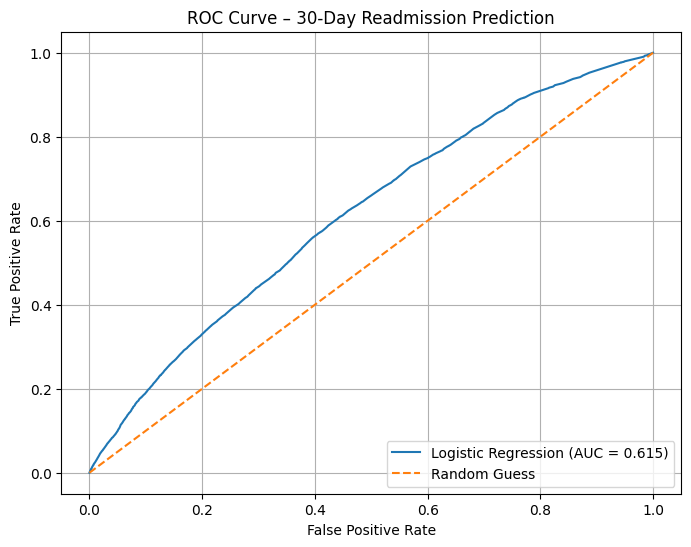

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – 30-Day Readmission Prediction")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [42]:
y_pred = model.predict(X_test)  # implicit 0.50 threshold


In [43]:
import numpy as np
from sklearn.metrics import classification_report

threshold = 0.30
y_pred_thresh = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_thresh))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00     68976
           1       0.18      1.00      0.31     15501

    accuracy                           0.18     84477
   macro avg       0.09      0.50      0.16     84477
weighted avg       0.03      0.18      0.06     84477



c:\Users\Warner_Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Warner_Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Warner_Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [44]:

import numpy as np

np.percentile(y_prob, [5, 10, 20, 30, 40, 50, 60, 70, 80, 90])


array([0.36219514, 0.36530769, 0.39268282, 0.43450785, 0.46511734,
       0.47766453, 0.50272157, 0.53706239, 0.55855676, 0.60596853])

In [45]:
threshold = 0.45
y_pred_thresh = (y_prob >= threshold).astype(int)
print(classification_report(y_test, y_pred_thresh))


              precision    recall  f1-score   support

           0       0.88      0.36      0.51     68976
           1       0.21      0.78      0.34     15501

    accuracy                           0.43     84477
   macro avg       0.55      0.57      0.42     84477
weighted avg       0.76      0.43      0.48     84477



In [46]:
threshold = 0.40
y_pred_thresh = (y_prob >= threshold).astype(int)
print(classification_report(y_test, y_pred_thresh))


              precision    recall  f1-score   support

           0       0.91      0.23      0.37     68976
           1       0.21      0.89      0.34     15501

    accuracy                           0.36     84477
   macro avg       0.56      0.56      0.35     84477
weighted avg       0.78      0.36      0.37     84477



In [47]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
best_idx = f1.argmax()

best_threshold = thresholds[best_idx]
best_threshold


0.4651650922460748

In [ ]:
y_pred_best = (y_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_best))


              precision    recall  f1-score   support

           0       0.88      0.43      0.58     68976
           1       0.22      0.73      0.34     15501

    accuracy                           0.49     84477
   macro avg       0.55      0.58      0.46     84477
weighted avg       0.76      0.49      0.53     84477



: 